In [13]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("state_info.csv")

In [15]:

co2_targets = {
"Andhra Pradesh":150,
"Arunachal Pradesh":4,
"Assam":35,
"Bihar":60,
"Chhattisgarh":110,
"Goa":6,
"Gujarat":220,
"Haryana":90,
"Himachal Pradesh":12,
"Jharkhand":85,
"Karnataka":170,
"Kerala":65,
"Madhya Pradesh":140,
"Maharashtra":310,
"Manipur":3,
"Meghalaya":6,
"Mizoram":2,
"Nagaland":2,
"Odisha":125,
"Punjab":70,
"Rajasthan":160,
"Sikkim":1,
"Tamil Nadu":200,
"Telangana":130,
"Tripura":5,
"Uttar Pradesh":290,
"Uttarakhand":18,
"West Bengal":180,
"Andaman and Nicobar Islands":1,
"Chandigarh":2,
"Dadra and Nagar Haveli and Daman and Diu":8,
"Delhi":70,
"Jammu and Kashmir":15,
"Ladakh":1,
"Lakshadweep":0.5,
"Puducherry":4
}
df["co2_emissions_mt"] = df["state"].map(co2_targets)



In [16]:


X = df.drop(["state","co2_emissions_mt"],axis=1)
y = df["co2_emissions_mt"]


X.head()

,population_growth_percent,vehicles_registered_million,gdp_per_capita_inr,electricity_consumption_kwh_per_capita,forest_cover_percent,economic_growth_percent,industrial_output_index,public_transport_usage_percent
0,11.1,14.0,242479,1200,23,7.5,110,26
1,26.0,0.3,205000,900,79,6.5,45,12
2,16.9,5.0,118000,950,36,7.8,70,20
3,25.4,12.0,54000,350,8,8.5,60,14
4,22.6,7.0,122000,1050,41,7.0,95,15


In [17]:
X_train,X_test,y_train,y_test = train_test_split( X, y, test_size=0.2 ,random_state=42 )

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("scaler",StandardScaler()),
    ("model",GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4
))
])

In [28]:
pipeline.fit(X_train,y_train)


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,learning_rate,0.05
,n_estimators,500
,subsample,1.0


In [29]:


predictions = pipeline.predict(X_test)

print("R2 Score:", r2_score(y_test,predictions))
print("MAE:", mean_absolute_error(y_test,predictions))

R2 Score: 0.7905067755918667
MAE: 29.692712283596386


In [30]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
pipeline,
X,
y,
cv=5,
scoring="r2"
)

print("Average R2:",scores.mean())

Average R2: 0.8208539907968693


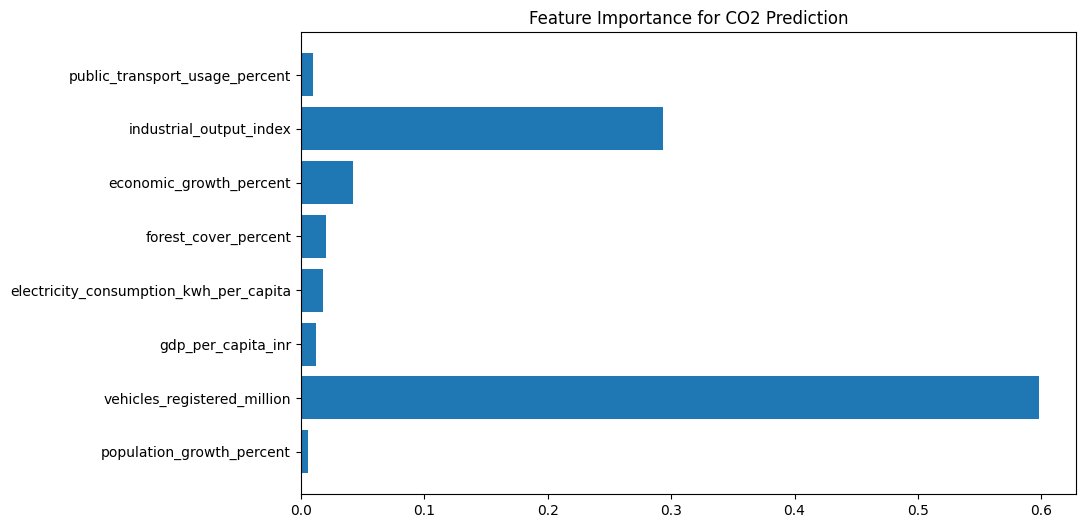

In [21]:
model = pipeline.named_steps["model"]

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

plt.barh(features,importance)

plt.title("Feature Importance for CO2 Prediction")

plt.show()

In [22]:



future_df = df.copy()


In [23]:

future_df = df.copy()


# assumptions for 2030 scenario

future_df["vehicles_registered_million"] *= 1.15
future_df["electricity_consumption_kwh_per_capita"] *= 1.20
future_df["gdp_per_capita_inr"] *= 1.30
future_df["forest_cover_percent"] *= 1.02
future_df["industrial_output_index"] *= 1.10


future_X = future_df.drop(["state","co2_emissions_mt"],axis=1)

future_predictions = pipeline.predict(future_X)


future_df["predicted_co2_2030"] = future_predictions


In [25]:
result = future_df[["state","co2_emissions_mt","predicted_co2_2030"]]

df1=result.sort_values("predicted_co2_2030",ascending=False)

df1
                       
                    

,state,co2_emissions_mt,predicted_co2_2030
25,Uttar Pradesh,290.0,227.383333
22,Tamil Nadu,200.0,210.750000
10,Karnataka,170.0,208.450000
6,Gujarat,220.0,206.100000
13,Maharashtra,310.0,203.373333
20,Rajasthan,160.0,188.094444
12,Madhya Pradesh,140.0,175.750000
23,Telangana,130.0,164.358333
27,West Bengal,180.0,162.412222
0,Andhra Pradesh,150.0,146.502778


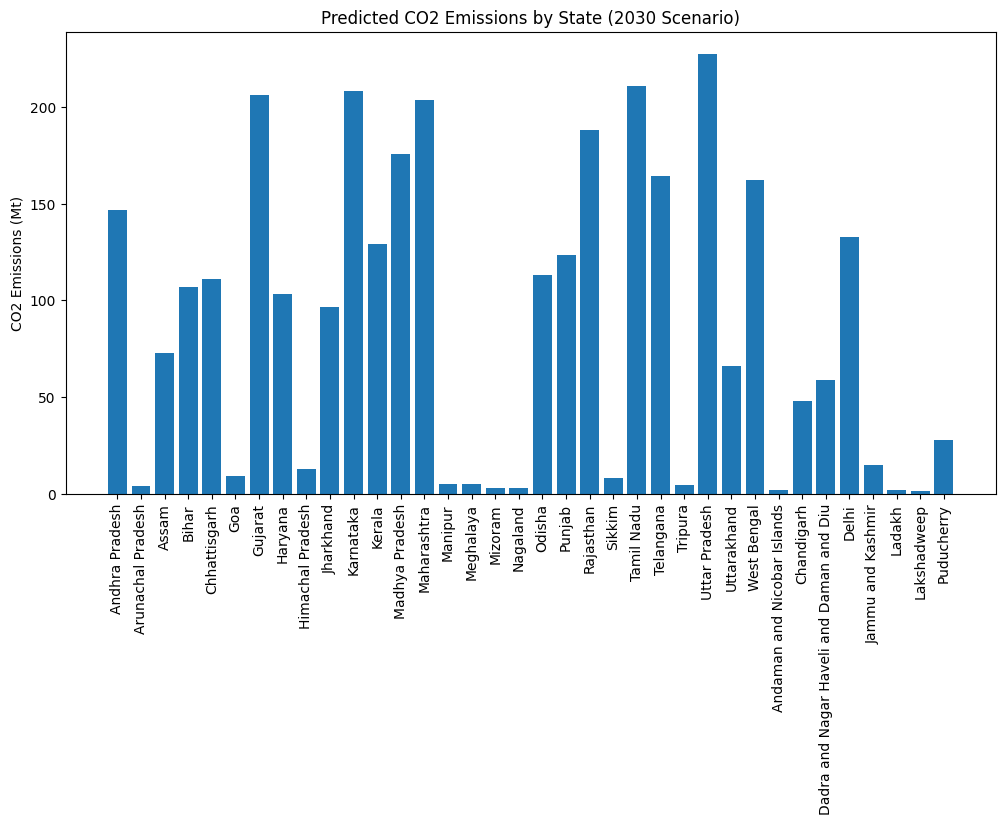

In [26]:




plt.figure(figsize=(12,6))

plt.bar(result["state"],result["predicted_co2_2030"])

plt.xticks(rotation=90)

plt.title("Predicted CO2 Emissions by State (2030 Scenario)")

plt.ylabel("CO2 Emissions (Mt)")

plt.show()



import pickle

pickle.dump(pipeline, open("co2_model.pkl","wb"))

